# SPICE-posed synthetic lunar satellite imagery

Demo: pose a synthetic pinhole camera using the **real LRO spacecraft trajectory** (NAIF SPICE kernels) at the timestamp of an actual LROC WAC EDR image, render a synthetic 256x256 image from real Lunaserv WMS DEM/imagery with NASA's Ames Stereo Pipeline `sat_sim`, and compare it against the real WAC data. See `../docs/plan.md` for the full phase-by-phase approach and `../docs/data-sources.md` for the researched specifics referenced below.

This notebook drives the scripts in `../scripts/` rather than duplicating their logic.

In [1]:
import sys, json, subprocess
sys.path.insert(0, '../scripts')

import numpy as np
import matplotlib.pyplot as plt
import rasterio

import build_camera_from_spice as bcs
import fetch_lunaserv
import fetch_wac_comparison

import os
os.makedirs('../output', exist_ok=True)

## Phase 2: SPICE-derived camera pose

Pose a pinhole camera at framelet 0 of WAC EDR product `M1329714703CE`, using LRO's real position/orientation (from NAIF SPICE kernels, in the `MOON_ME` frame) at that instant.

In [2]:
camera_info = bcs.build('../output/camera_frame440.tsai')
print(json.dumps(camera_info, indent=2, default=str))

{
  "et": 628347820.8660157,
  "camera_center_moon_me_m": [
    -87699.89132213652,
    216746.2705415187,
    -1790709.4927152114
  ],
  "slant_range_km": 68.52347913933363,
  "off_nadir_deg": 1.1172594342747753,
  "focal_length_px": 685.2347913933363,
  "footprint_lonlat_deg": {
    "center": [
      111.91573112388885,
      -82.6024115539369
    ],
    "top_left": [
      116.3217983381552,
      -82.43944444048847
    ],
    "top_right": [
      113.11126540774362,
      -83.18458689379815
    ],
    "bottom_left": [
      110.90227958617815,
      -82.02287826796932
    ],
    "bottom_right": [
      107.31249309671769,
      -82.72101247445703
    ]
  }
}


Sanity check: altitude and sub-spacecraft location should be consistent with LRO's known Fourth Extended Science Mission frozen elliptical orbit (low periapsis over the south pole).

In [3]:
print(f"Slant range to surface: {camera_info['slant_range_km']:.2f} km")
print(f"Off-nadir angle: {camera_info['off_nadir_deg']:.2f} deg")
print(f"Ground footprint center (lon, lat): {camera_info['footprint_lonlat_deg']['center']}")

Slant range to surface: 68.52 km
Off-nadir angle: 1.12 deg
Ground footprint center (lon, lat): (np.float64(111.91573112388885), np.float64(-82.6024115539369))


## Phase 3: DEM + ortho from Lunaserv WMS

Fetch `luna_wac_global` (visible mosaic) and `luna_wac_dtm_numeric_meters_absolute` (GLD100 DEM, converted from planetocentric radius to elevation -- see `docs/data-sources.md`) for the footprint above, through the local cache.

In [4]:
lunaserv_result = fetch_lunaserv.fetch_dem_and_ortho(output_dir='../output')
print(json.dumps({k: v for k, v in lunaserv_result.items() if k != 'camera_info'}, indent=2, default=str))

ROI bbox (lon/lat deg): (np.float64(104.60970152428644), np.float64(-83.5330994815468), np.float64(119.02458991058646), np.float64(-81.67436568022066)), size 563x564 px (~100.0 m/px)


	--> Setting number of processing threads to: 4
Writing log: ../output/dem_filled-log-dem_mosaic-07-29-2247-45.txt
Using output no-data value: -3.40282e+38
Determining the bounding boxes of the inputs.
        --> [*************************************************************]
Mosaic size: 563 x 564 pixels.
Number of tiles: 1 x 1 = 1.
Reading the input DEMs.
Reading the input DEMs.
Loading: ../output/dem_elevation.tif
Writing: ../output/dem_filled-tile-0.tif
        --> [.............................................................] 0%

        --> [*************************************************************]
Re-writing with blocks of size: 256 x 256.
        --> [*************************************************************]
Number of valid (not no-data) pixels written: 317532.
{
  "ortho": "/workspace/cache/lunaserv/luna_wac_global/104.609702_-83.533099_119.024590_-81.674366_563x564.tif",
  "dem": "../output/dem_filled-tile-0.tif",
  "bbox": [
    104.60970152428644,
    -83.5330994815468,
    119.02458991058646,
    -81.67436568022066
  ],
  "width": 563,
  "height": 564
}


/tmp/ipykernel_9/2627465292.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  ortho = src.read(1)
/tmp/ipykernel_9/2627465292.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem = src.read(1)


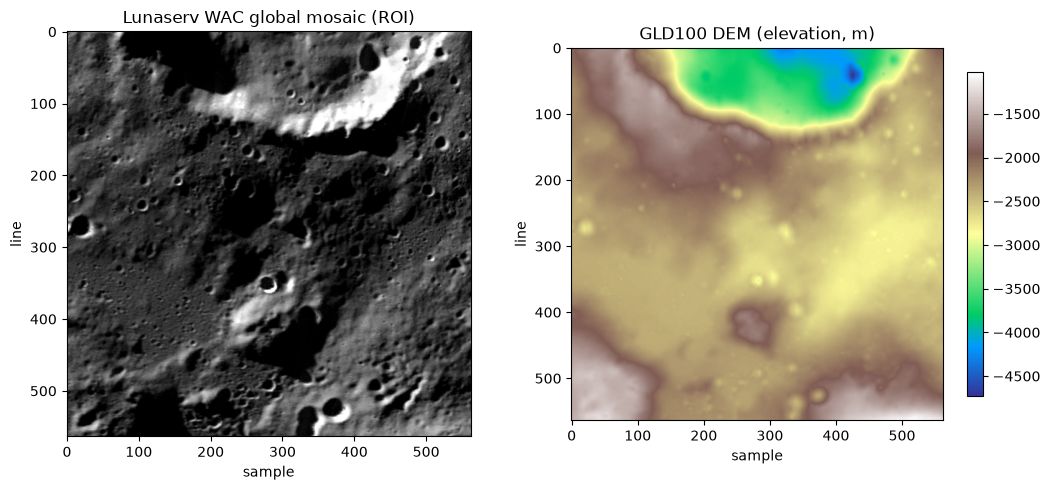

In [5]:
with rasterio.open(lunaserv_result['ortho']) as src:
    ortho = src.read(1)
    ortho_transform = src.transform
with rasterio.open(lunaserv_result['dem']) as src:
    dem = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(ortho, cmap='gray')
axes[0].set_title('Lunaserv WAC global mosaic (ROI)')
im = axes[1].imshow(dem, cmap='terrain')
axes[1].set_title('GLD100 DEM (elevation, m)')
fig.colorbar(im, ax=axes[1], shrink=0.8)
for ax in axes:
    ax.set_xlabel('sample'); ax.set_ylabel('line')
plt.tight_layout()

### Camera footprint over the DEM

Plot the SPICE-derived camera's ground footprint (corners + center) on top of the ortho mosaic, to visually confirm the pose lands where expected.

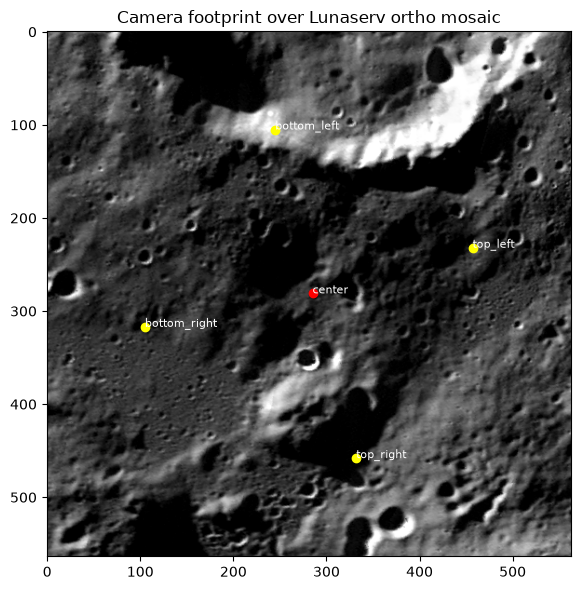

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(ortho, cmap='gray')
for name, lonlat in camera_info['footprint_lonlat_deg'].items():
    if lonlat is None:
        continue
    lon, lat = lonlat
    row, col = rasterio.transform.rowcol(ortho_transform, lon, lat)
    ax.plot(col, row, 'o', color='red' if name == 'center' else 'yellow')
    ax.annotate(name, (col, row), color='white', fontsize=8)
ax.set_title('Camera footprint over Lunaserv ortho mosaic')
plt.tight_layout()

## Phase 4: render with `sat_sim` + the real camera pose

Runs `../scripts/run_sat_sim.sh`, which:
1. Calls `sat_sim --camera-list` with the Phase 2 `.tsai` camera against the Phase 3 DEM/ortho, producing the synthetic 256x256 image.
2. Calls ASP's `cam_gen` to convert that exact camera to a CSM Frame model-state JSON (the "ISD" sidecar) -- `--save-as-csm` is a no-op in `--camera-list` mode, see `docs/data-sources.md`.

	--> Setting number of processing threads to: 4

Creating output directory: "/workspace/output/render".
Writing log: /workspace/output/render/run-log-sat_sim-07-29-2247-118.txt
Reading: ../output/dem_filled-tile-0.tif
Using: nan.
Reading: /workspace/cache/lunaserv/luna_wac_global/104.609702_-83.533099_119.024590_-81.674366_563x564.tif
Reading: /workspace/output/camera_list.txt
Generating images.
Writing: /workspace/output/render/run-camera_frame440.tif
        --> [.............................................................] 0%

        --> [*************************************************************]
Writing: /workspace/output/render/run-images.txt


	--> Setting number of processing threads to: 4
Loading camera model: /workspace/output/render/run-camera_frame440.tif /workspace/output/camera_frame440.tsai
Guessed the datum from camera position.
Using datum: Geodetic Datum --> Name: D_MOON  Spheroid: MOON  Semi-major axis: 1737400  Semi-minor axis: 1737400  Meridian: Reference meridian at 0  Proj4 Str: +proj=longlat +R=1737400 +no_defs


Refining camera intrinsics and pose.
Refine focal length: 0
Refine optical center: 0
Refine other intrinsics (distortion): 0
Errors of pixel projection in the camera with refined intrinsics:
Min:    2.2906093030604505e-10
Median: 2.297989926265142e-08
Mean:   2.2189675770788982e-08
StDev:  8.3570831024889203e-09
Max:    4.4178091017688767e-08
Num samples: 10201
Output camera center lon, lat, and height above datum: Vector3(112.02924407078079,-82.560858225560352,68509.9379792416)
Writing: /workspace/output/render/run-camera_frame440.json


/opt/venv/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_9/2549467607.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  synthetic = src.read(1)


Text(0, 0.5, 'line')

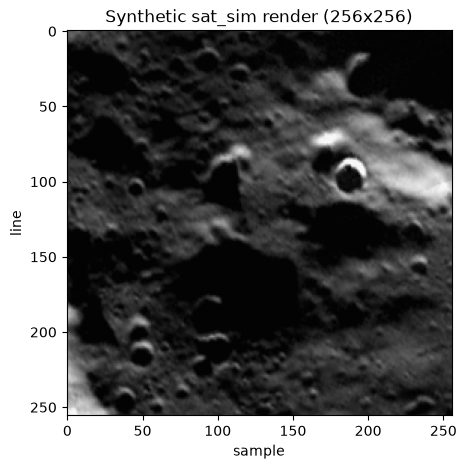

In [7]:
subprocess.run(['bash', '../scripts/run_sat_sim.sh'], check=True)

with rasterio.open('../output/render/run-camera_frame440.tif') as src:
    synthetic = src.read(1)

plt.figure(figsize=(5, 5))
plt.imshow(synthetic, cmap='gray')
plt.title('Synthetic sat_sim render (256x256)')
plt.xlabel('sample'); plt.ylabel('line')

### The CSM / "ISD" JSON sidecar

The state file's first line is a bare model-name string (not JSON) -- standard CSM "state string" convention; skip it before parsing.

In [8]:
with open('../output/render/run-camera_frame440.json') as f:
    lines = f.readlines()
model_name = lines[0].strip()
csm_state = json.loads(''.join(lines[1:]))

print('Model name:', model_name)
for key in ['m_focalLength', 'm_nLines', 'm_nSamples', 'm_ccdCenter', 'm_currentParameterValue']:
    print(f'{key}: {csm_state[key]}')

Model name: USGS_ASTRO_FRAME_SENSOR_MODEL
m_focalLength: 685.2347913933363
m_nLines: 256
m_nSamples: 256
m_ccdCenter: [128.0, 128.0]
m_currentParameterValue: [-87699.8913293379, 216746.2705342426, -1790709.4927325614, 0.054293665975566154, 0.05045587136795482, -0.3142026311616052, 0.9464581921303014]


`m_currentParameterValue`'s first 3 entries are the camera center (X, Y, Z, meters, MOON_ME frame) and the last 4 are the orientation quaternion -- matching the `C`/`R` we computed from SPICE in Phase 2.

## Phase 5: a recognizable image from the real WAC CDR

WAC is a push-frame camera: each 78-line frame multiplexes 7 filters (2 UV @ 4 TDI lines + 5 VIS @ 14 TDI lines), and per the official LROC SIS, the CDR "will require further processing to separate framelets into their respective bands ... in order to be viewed as a standard image." `fetch_wac_comparison.fetch_vis_mosaic()` does that: it pulls one VIS filter's 14-line block (an offset guaranteed pure-VIS regardless of WAC's current yaw-dependent band ordering -- see the module docstring) from many consecutive frames and stacks them, which is exactly how WAC's push-frame design builds continuous coverage.

This also uncovered why frame 0 never looked like anything: the first ~210 of this product's 538 frames are in near-total shadow (I/F at the noise floor). `build_camera_from_spice.TARGET_FRAME_INDEX` was moved to 440, in a long, stable, well-lit stretch -- so both the synthetic camera above and this real-image comparison land on visible terrain.

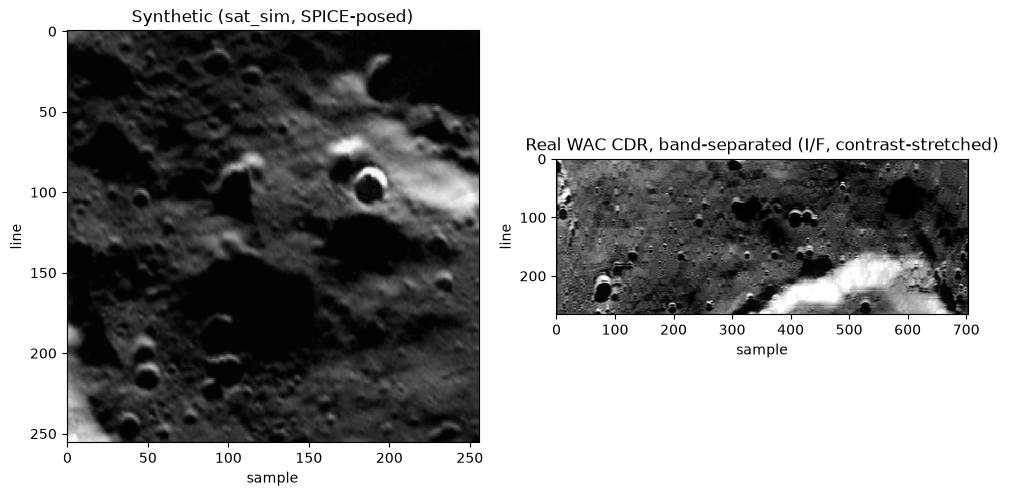

In [9]:
vis_mosaic = fetch_wac_comparison.fetch_vis_mosaic()
valid_mask = vis_mosaic != fetch_wac_comparison.MISSING_CONSTANT
p2, p98 = np.percentile(vis_mosaic[valid_mask], [2, 98])
display_mosaic = np.where(valid_mask, vis_mosaic, p2)  # fill missing edge columns with the low end of the stretch

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(synthetic, cmap='gray')
axes[0].set_title('Synthetic (sat_sim, SPICE-posed)')
axes[1].imshow(display_mosaic, cmap='gray', vmin=p2, vmax=p98)
axes[1].set_title('Real WAC CDR, band-separated (I/F, contrast-stretched)')
for ax in axes:
    ax.set_xlabel('sample'); ax.set_ylabel('line')
plt.tight_layout()

## Summary

- Picked a real LROC WAC EDR (`M1329714703CE`), computed LRO's true position/orientation at framelet 440's timestamp directly in the Moon's `MOON_ME` frame via `spiceypy`, using a minimal, selectively-cached SPICE kernel set (see `docs/caching.md`).
- Built a `.tsai` Pinhole camera from that pose and rendered a synthetic 256x256 image with ASP's `sat_sim`, fed by real DEM/imagery pulled live from Lunaserv WMS for the camera's own computed ground footprint.
- Produced a CSM/"ISD" JSON sidecar for the rendered camera (`cam_gen`), and cross-validated the whole pose pipeline: `cam_gen` independently recovered the same sub-spacecraft geodetic position from the `.tsai`'s raw ECEF pose that the original SPICE computation produced.
- Compared against a properly band-separated crop of the real WAC CDR from the same part of the swath -- which required both de-interleaving WAC's push-frame format and discovering (then avoiding) a long shadowed stretch at the start of this particular product.